In [ ]:
import ee
import folium

# Authenticate and initialize with the specific project ID
ee.Authenticate()
ee.Initialize(project='ee-ishansinhagzb')

In [ ]:
import ee
import folium

# Initialize the Earth Engine library
try:
    ee.Initialize(project='ee-ishansinhagzb')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='ee-ishansinhagzb')

# Define the dataset and filter for a specific date range
dataset = ee.ImageCollection('NASA/GRACE/MASS_GRIDS_V04/MASCON') \
                  .filter(ee.Filter.date('2002-03-31', '2024-09-30'))

# Select the equivalent water thickness band and get the mean image for that period
equivalentWaterThickness = dataset.select('lwe_thickness').mean()

# Get the USA boundary from the LSIB dataset
usa_boundary = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
    .filter(ee.Filter.eq('country_na', 'United States'))

# Clip the data to the USA boundary
equivalentWaterThickness_usa = equivalentWaterThickness.clip(usa_boundary)

# Define visualization parameters
vis_params = {
  'min': -25.0,
  'max': 25.0,
  'palette': ['001137', '01abab', 'e7eb05', '620500'],
}

# Helper function to add EE layers to folium
def add_ee_layer(self, ee_image_object, vis_params, name):
  map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
  folium.raster_layers.TileLayer(
    tiles = map_id_dict['tile_fetcher'].url_format,
    attr = 'Map Data &copy; <a href="https://earthengine.google.com/">Google Earth Engine</a>',
    name = name,
    overlay = True,
    control = True
  ).add_to(self)

# Add the method to folium.Map
folium.Map.add_ee_layer = add_ee_layer

# Create a map centered on the USA
my_map = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Add the layer to the map
my_map.add_ee_layer(equivalentWaterThickness_usa, vis_params, 'Equivalent Water Thickness (USA)')

# Add a layer control panel
my_map.add_child(folium.LayerControl())

# Display the map
my_map

In [ ]:
import branca

# Define the legend HTML
legend_html = '''
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 250px;
    height: 120px;
    z-index:9999;
    font-size:14px;
    background-color: white;
    opacity: 0.8;
    border: 2px solid grey;
    padding: 10px;
    ">
    <b>Equivalent Water Thickness (cm)</b><br>
    <i style="background: #620500; width: 20px; height: 10px; display: inline-block;"></i> 25.0<br>
    <i style="background: #e7eb05; width: 20px; height: 10px; display: inline-block;"></i> 8.3<br>
    <i style="background: #01abab; width: 20px; height: 10px; display: inline-block;"></i> -8.3<br>
    <i style="background: #001137; width: 20px; height: 10px; display: inline-block;"></i> -25.0<br>
</div>
'''

# Create a branca element and add it to the map
legend = branca.element.Element(legend_html)
my_map.get_root().html.add_child(legend)
display(my_map)

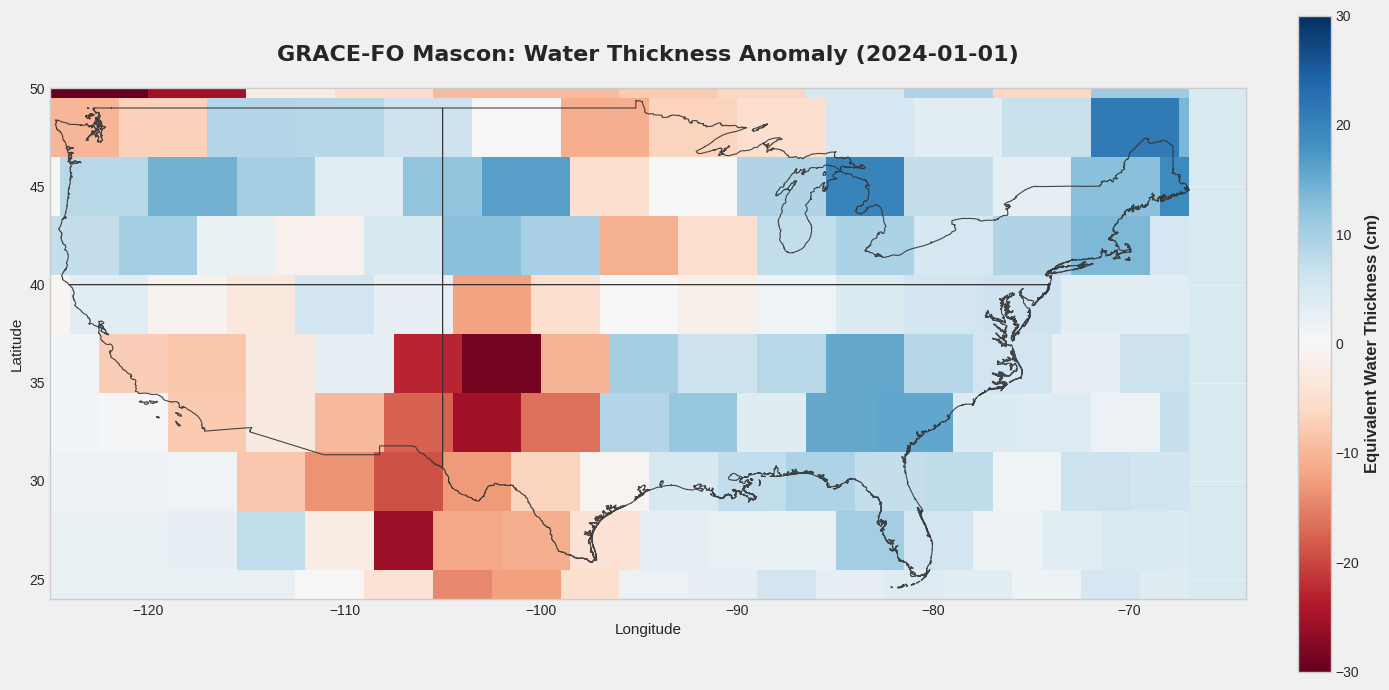

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a specific image (e.g., January 2024)
target_date = '2024-01-01'
specific_img = collection.filterDate(target_date, '2024-02-01').first().select('lwe_thickness')

# Define the region for sampling (CONUS)
roi = ee.Geometry.Rectangle([-125, 24, -67, 50])

# Get USA boundary coordinates
usa = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017").filter(ee.Filter.eq('country_na', 'United States'))
usa_geom = usa.geometry().getInfo()['coordinates']

# Unmask and sample
sample_data = specific_img.unmask(0).sampleRectangle(region=roi)
lwe_array = np.array(sample_data.get('lwe_thickness').getInfo())

# Aesthetic Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7), facecolor='#f0f0f0')
ax.set_facecolor('#d9e9f0') # Light blue for ocean/background

# Main Data using a diverging colormap (Red-White-Blue)
im = ax.imshow(lwe_array, extent=[-125, -67, 24, 50], cmap='RdBu', vmin=-30, vmax=30, zorder=1)

# Overlay USA boundary with cleaner lines
for poly in usa_geom:
    for ring in poly:
        x, y = zip(*ring)
        ax.plot(x, y, color='#333333', linewidth=0.8, alpha=0.9, zorder=2)

# Add a refined colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Equivalent Water Thickness (cm)', fontsize=12, fontweight='bold')

# Title and Labels
plt.title(f'GRACE-FO Mascon: Water Thickness Anomaly ({target_date})',
          fontsize=16, fontweight='bold', pad=20, fontname='DejaVu Sans')
plt.xlabel('Longitude', fontsize=11)
plt.ylabel('Latitude', fontsize=11)

# Clean up axes
ax.tick_params(axis='both', which='major', labelsize=10)
ax.grid(color='white', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import ee

# Flag for test run: set to False to export all available data
test_run = False

# Define the USA boundary
usa_boundary = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
    .filter(ee.Filter.eq('country_na', 'United States')).geometry()

# Load the dataset (GRACE-FO specifically or general GRACE Mascon)
# NASA/GRACE/MASS_GRIDS_V04/MASCON covers the operational duration including FO
collection = ee.ImageCollection('NASA/GRACE/MASS_GRIDS_V04/MASCON')

# If test_run is True, just take one image
if test_run:
    export_collection = collection.filterDate('2020-01-01', '2020-02-01')
else:
    export_collection = collection

img_list = export_collection.toList(export_collection.size())
count = img_list.size().getInfo()

print(f"Found {count} images to process.")

for i in range(count):
    image = ee.Image(img_list.get(i))

    # Select bands and clip
    processed_img = image.select(['lwe_thickness', 'uncertainty']).clip(usa_boundary)

    # Get date for naming
    date = ee.Date(image.get('system:time_start'))
    year = date.get('year').getInfo()
    month = date.get('month').getInfo()
    filename = f'GRACE_{year}_{month:02d}'

    # Define Drive Export task
    task = ee.batch.Export.image.toDrive(
        image=processed_img,
        description=filename,
        folder='MSUGW_GRACE',
        fileNamePrefix=filename,
        region=usa_boundary,
        scale=55660, # Original resolution
        fileFormat='GeoTIFF'
    )

    task.start()
    print(f"Started export task for: {filename}")

Found 238 images to process.
Started export task for: GRACE_2002_04
Started export task for: GRACE_2002_05
Started export task for: GRACE_2002_07
Started export task for: GRACE_2002_08
Started export task for: GRACE_2002_09
Started export task for: GRACE_2002_10
Started export task for: GRACE_2002_11
Started export task for: GRACE_2002_12
Started export task for: GRACE_2003_01
Started export task for: GRACE_2003_02
Started export task for: GRACE_2003_03
Started export task for: GRACE_2003_04
Started export task for: GRACE_2003_06
Started export task for: GRACE_2003_07
Started export task for: GRACE_2003_08
Started export task for: GRACE_2003_09
Started export task for: GRACE_2003_10
Started export task for: GRACE_2003_11
Started export task for: GRACE_2003_12
Started export task for: GRACE_2004_02
Started export task for: GRACE_2004_02
Started export task for: GRACE_2004_03
Started export task for: GRACE_2004_04
Started export task for: GRACE_2004_05
Started export task for: GRACE_2004